In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib
import pointpats

# Пуассоновский процесс

1. Моделировать процесс восстановления (то есть точечный процесс с расстояниями между скачками с указанным распределением) с а) exp(λ) шагами, б) R[0, 1] распределением. Исследовать численно предельное распределение эксцесса и сравнить с распределением шага.

In [2]:
def model_excess(tau_gen, num_obs, num_gen=100):
    # model process
    tau = tau_gen(size = num_gen)
    time_full = np.sum(tau)
    obs_times = time_full * np.arange(1, num_obs) / num_obs
    excess = []

    # get excess
    time_sum = 0
    j = 0
    for i in range(num_obs-1):
        while time_sum < obs_times[i]:
            time_sum += tau[j]
            j += 1
        excess.append(time_sum - obs_times[i])
    return excess


def compare_excess(num_obs = 100, lamda = 3, num_gen = 100):
    # exp
    excess = model_excess(partial(stats.expon.rvs, scale = 1/lamda), num_obs, num_gen)
    x = np.linspace(0, 2, 1000)
    sns.ecdfplot(excess, label = f'Empirical excess ECDF')
    plt.plot(x, stats.expon.cdf(x, scale = 1/lamda), label = f'Exp({lamda}) CDF')
    plt.legend()
    plt.title(f'Exp({lamda})')
    plt.show()

    
    # R[0,1]
    excess = model_excess(partial(stats.uniform.rvs), num_obs, num_gen)
    x = np.linspace(0, 1, 1000)
    sns.ecdfplot(excess, label = f'Empirical excess ECDF')
    plt.plot(x, stats.uniform.cdf(x), label = f'R[0,1] CDF')
    plt.legend()
    plt.title(f'R[0,1]')
    plt.show()




реализация AD проверки простой гипотезы

In [24]:
with open('ad_mc.txt', 'r') as f:
    T_ad_file = [float(line.strip()) for line in f if line.strip()]

def ad_stat(data, f0):
  data.sort()
  n = len(data)
  r_data = [f0(i) for i in data]
  stat = -n-sum([((2*(i+1)-1)/n)*(np.log(r_data[i])+np.log(1-r_data[n-1-i])) for i in range(n)])
  return stat

def ad_pval(x_data, f0, T = T_ad_file, a =0.05):
  N = len(T)
  stat = ad_stat(x_data, f0)
  k = 0
  for i in range(N):
    if T[i] < stat:
      k+=1
    else:
      break
  pval = 1 - k/N
  return pval

In [4]:
def check_hyp(num_sim = 100 ,num_obs = 100, num_gen = 100):
    lamda = 3
    gens = [[partial(stats.expon.rvs, scale = 1/lamda), partial(stats.expon.cdf, scale = 1/lamda), f'Exp({lamda})'],
            [stats.uniform.rvs, stats.uniform.cdf, f'R[0,1]']]
    for gen in gens:
        p_val = []
        for _ in range(num_sim):
            data = model_excess(gen[0], num_obs, num_gen)
            p_val.append(ad_pval(data, gen[1]))
        
        x = np.linspace(0,1,100)
        plt.plot(x,x, linestyle = '--', color= 'black')
        sns.ecdfplot(p_val, label = gen[2])
        plt.legend()
        plt.show()



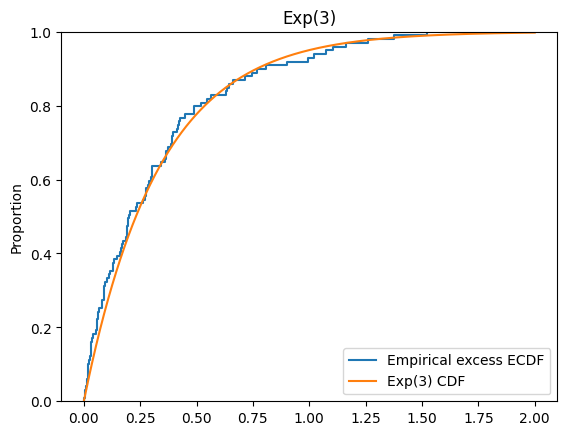

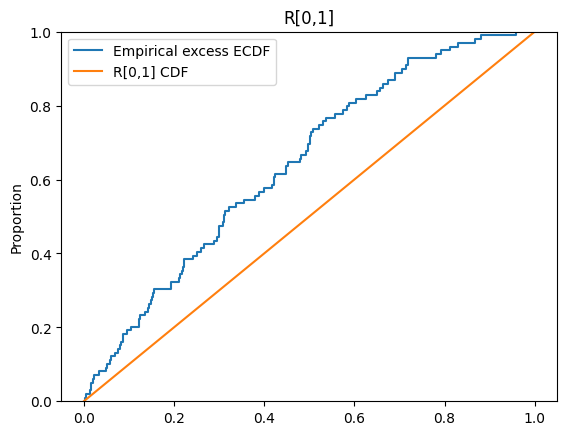

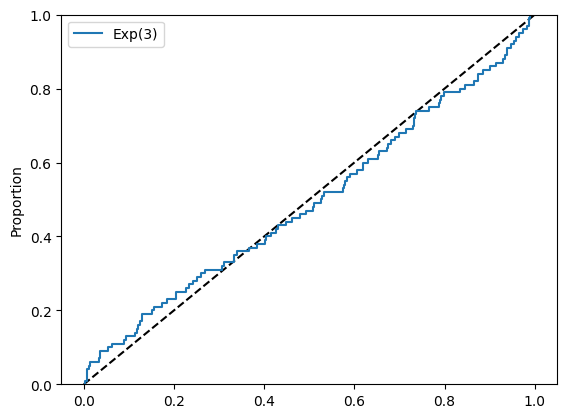

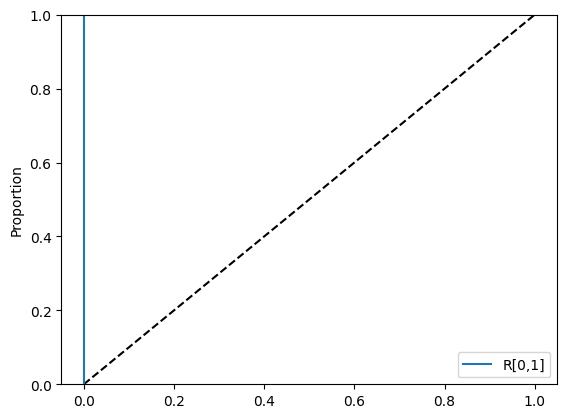

In [15]:
compare_excess()
check_hyp()

2. Исследовать парадокс времени ожидания: моделировать а) пуассоновский поток с λ = 2 б) процесс с
Gamma(2, 1/4) распределением между скачками в) процесс с R[0, 1] распределением между скачками.
Рассмотреть среднюю длину промежутка, накрывающего момент 100 и соотнести с математическим
ожиданием между промежутками.

In [2]:
def wait_paradox(t = 100, num_sim = 100, lamda = 2, a = 2, beta = 1/4):
    gens = [[partial(stats.expon.rvs, scale = 1/lamda), 'Exp(2)' ],
            [partial(stats.gamma.rvs,  a = a, scale = beta), 'Gamma(2, 1/4)'],
            [stats.uniform.rvs , 'R[0,1]']]
    
    for gen in gens:
        true_mean = 1/2
        mean_emp = 0
        mean_wait = 0

        for _ in range(num_sim):
            num_gen = 500
            tau = gen[0](size = num_gen)

            time_sum  =0
            j = 0
            while time_sum < t:
                time_sum += tau[j]
                j += 1
            leap = tau[j-1]
            wait = time_sum - t
            mean_emp += leap
            mean_wait += wait
        print(gen[1])
        print(f'True mean = {true_mean}, empirical mean = {mean_emp/num_sim}, empirical wait = {mean_wait/num_sim}\n')



In [3]:
wait_paradox()

Exp(2)
True mean = 0.5, empirical mean = 1.0069454913010067, empirical wait = 0.4895212253025962

Gamma(2, 1/4)
True mean = 0.5, empirical mean = 0.7685916019006674, empirical wait = 0.37717172529342063

R[0,1]
True mean = 0.5, empirical mean = 0.7035851391352078, empirical wait = 0.3759590498654046



3. Исследуем условное свойство пуассоновского потока. Сгенерируйте точки пуассоновского потока а) на
прямой б*) на плоскости и проверьте точки, попавшие на а) отрезок б*) квадрат на равномерность.

In [11]:
def conditional_property(a = 1, b = 30):
    num_sim = 1000
    n_fix = 45
    p_val = []
    
    for _ in range(num_sim):
        tau = stats.expon.rvs(scale = 1/2, size = 100)
        points = np.cumsum(tau)
        data = (points[(points >= a) & (points <= b)] - a) / b
        if 1:
            p_val.append(ad_pval(data, stats.uniform.cdf))

    x = np.linspace(0,1,100)
    plt.plot(x,x, linestyle='--', color = 'black')
    sns.ecdfplot(p_val, label=f'P-value ECDF')
    plt.legend()
    plt.show()




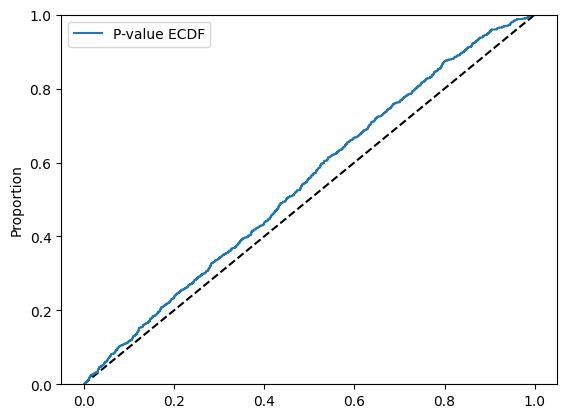

In [12]:
conditional_property()

In [21]:
def ks_un_stat(X, Y):
    X = np.asarray(X)
    Y = np.asarray(Y)
    n = X.shape[0]
    
    max_diff = 0
    for i, x in enumerate(X):
       
        for j, y in enumerate(Y):
            H_xy = np.sum((X <= x) & (Y <= y)) / n
            H_xy_l = H_xy - 1/n
            H_xy_lr = H_xy - 2/n

            diff = np.abs(H_xy - x*y)
            diff_l = np.abs(H_xy_l - x*y)
            diff_lr = np.abs(H_xy_lr - x*y)

            max_diff = max(diff, max_diff, diff_l, diff_lr)
    
    return np.sqrt(n)*max_diff


def ks_un_montecarlo(n = 500, N = 100):
    T = []
    for _ in range(N):
        x = stats.uniform.rvs(size = n)
        y = stats.uniform.rvs(size = n)
        T.append(ks_un_stat(x,y))
    return sorted(T)

def ks_un(x, y, T):
    N = len(T)
    stat = ks_un_stat(x, y)
    k = 0
    for i in range(N):
        if T[i] < stat:
            k+=1
        else:
            break
    pval = 1 - k/N
    return stat, pval

In [32]:
#НЕ ЗАПУСКАТЬ
T_ks_ind = ks_un_montecarlo()

with open('ks_un_mc.txt', 'w') as f:
    f.write('\n'.join(map(str, T_ks_ind)))

In [22]:
with open('ks_un_mc.txt', 'r') as f:
    T_ks_un_file = [float(line.strip()) for line in f if line.strip()]

In [29]:
def generate_poiss_plane(center = [0,0], lamda = 1, num_points = 10):
    points = np.zeros((num_points, 2))
    phi = stats.uniform.rvs(0,2*np.pi, size = num_points)
    rads = np.zeros(num_points)
    u = stats.uniform.rvs()
    rads[0] = np.sqrt(-np.log(1-u)/(np.pi*lamda))
    points[0][0] = rads[0]*np.cos(phi[0])
    points[0][1] = rads[0]*np.sin(phi[0])
    for point in range(1, num_points):
        u = stats.uniform.rvs()
        r1 = rads[point-1]
        rads[point] = np.sqrt(r1**2-np.log(1-u)/(lamda*np.pi))
        points[point][0] = rads[point]*np.cos(phi[point])
        points[point][1] = rads[point]*np.sin(phi[point])
    return points


        

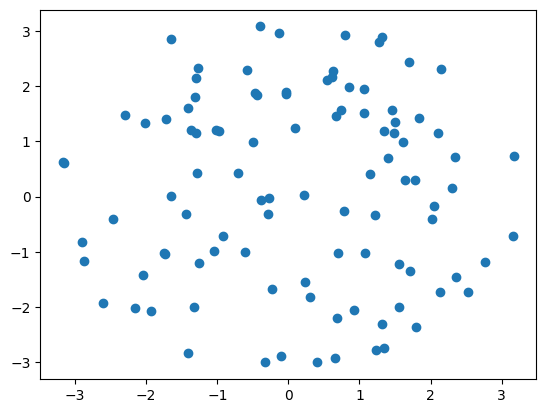

In [37]:
data = generate_poiss_plane(lamda = 3, num_points = 100)
x = [point[0] for point in data]
y = [point[1] for point in data]
plt.scatter(x, y)

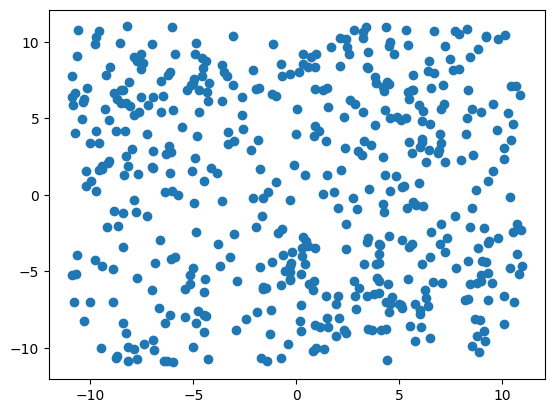

In [28]:
a = (-1,-1)
b = (1, 1)
box = np.array([a[0]- 10, a[1] - 10, b[0] + 10, b[1]+ 10])
        
data = pointpats.random.poisson(hull = box, intensity = 1)
x = [point[0] for point in data]
y = [point[1] for point in data]
plt.scatter(x, y)

In [34]:
def conditional_property_plane(a = (-1,-1), b = (1, 1)):
    num_sim = 1000
    n_fix = 100
    p_val = []
    pval_x= []
    pval_y = []
    num_points = 0
    for _ in range(num_sim):
        box = np.array([a[0]- 10, a[1] - 10, b[0] + 10, b[1]+ 10])
        
        points = generate_poiss_plane(num_points=100, lamda = 3)
        mask = (points[:, 0] >= a[0]) & (points[:, 0] <= b[0]) & (points[:, 1] >= a[1]) & (points[:, 1] <= b[1])

        data = (points[mask] - a) / [b[0] - a[0], b[1] - a[1]]
        if 1:
            num_points += 1
            x = [point[0] for point in data]
            y = [point[1] for point in data]
            p_val.append(ks_un(x, y, T = T_ks_un_file)[1])
            #pval_x.append(ad_pval(x, stats.uniform.cdf))
            #pval_y.append(ad_pval(y, stats.uniform.cdf))

    x = np.linspace(0,1,100)
    plt.plot(x,x, linestyle='--', color = 'black')
    sns.ecdfplot(p_val, label=f'P-value ECDF')
    #sns.ecdfplot(pval_x, label=f'X coordinate')
    #sns.ecdfplot(pval_y, label=f'Y coordinate')
    plt.legend()
    plt.show()
    print(num_points)

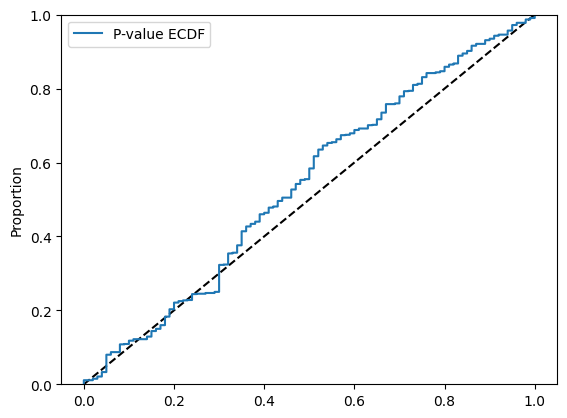

1000


In [35]:
conditional_property_plane()

4. В файле Coal Mining Disaster приведены данные о числе заболеваний в Великобритании в различные
годы. Проверить гипотезу о том, что болезни представляют собой однородный пуассоновский поток.

In [8]:
data = np.loadtxt('coal_mining.csv', delimiter=';')

X = data[:, -1].flatten()
n = len(X)
mid = int(n/2)
X_1 = X[:mid]
X_2 = X[mid:]

#Критерий однородности этих промежутков

p_value = stats.mannwhitneyu(X_1, X_2, method = 'exact').pvalue

if(p_value < 0.05):
    print("неоднородны")
else:
    print("однородны")

неоднородны


5. *Воспользуемся условным свойством неоднородного пуассоновского потока для моделирования выбор-
ки с заданной плотностью. Создать генератор выбороки случайного размера из 

а) распределения с
плотностью sin x на [0, π] 

б) треугольной плотностью x на [0,1], 2 − x на [1, 2]. 

Построить гистограммы
и убедиться в том, что плотность получилась требуемой. Для моделирования потока с заданной интен-
сивностью просто ждите небольшое время dt и разыгрывайте попала ли точка потока на него исходя из
вероятности λ(t)dt. Увеличивайте λ(x) в константу раз, чтобы делать выборку большего или меньшего
размера.

![опа картинка](poiss_cond.png)

In [ ]:
def sin_density(t, mult = 10):
    return np.sin(t) * mult/2

def tri_density(t,mult = 10):
    if  t <= 1:
        return t*mult
    if 1 < t <= 2:
        return (2- t)*mult
    return 0
    

def model_poiss(lamda, T = 3.15):
    t = 0.01
    cur_time = 0
    points = []
    while cur_time < T:
        r = stats.uniform.rvs()
        if r < lamda(cur_time)*t:
            points.append(cur_time)
        cur_time += t
    return points


def model_density(lamda, T, density):
    num_sim = 10000
    data = []

    for _ in range(num_sim):
        points = model_poiss(lamda, T)
        if len(points) == 10:
            data += points
    
    plt.hist(data, density = True, bins = 20)
    x = np.linspace(0,T, 500)
    dens = []
    for x in range(500):
        dens.append(density(x*T/500))
    plt.plot(T*np.arange(500)/500, dens, label= 'True density')
    plt.legend()
    plt.show()




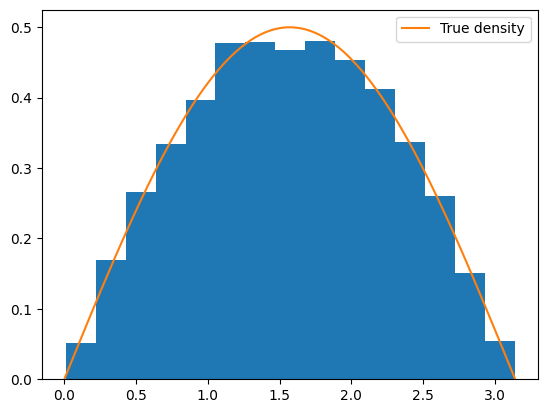

In [81]:
model_density(partial(sin_density, mult = 10), T = np.pi, density = partial(sin_density, mult = 1))

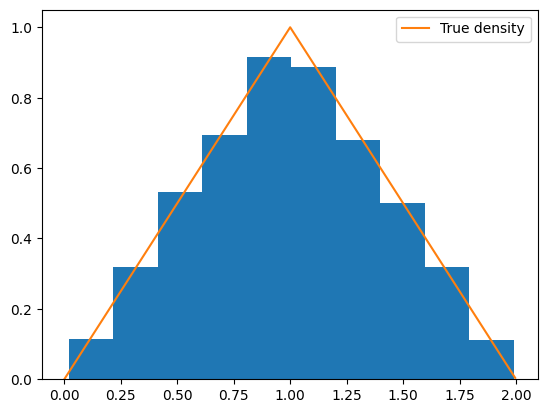

In [88]:
model_density(tri_density, T = 2, density = partial(tri_density, mult = 1))